# Week 3 Coding

Three tasks, each connected to the problem set: **C1** ↔ P1/P2, **C2** ↔ P3/P8/P11, **C3** ↔ P6.

**Predict first.** Before running any check cell, write down on paper what the output will be.

**How to access and work in this notebook.** Access this notebook through the Moodle activity **“L03 - Post-class - Jupyter Notebook Link.”** The first time you access the exercise, click **“Get a copy of the assignment”** to create your personal copy in your ETH JupyterHub workspace. Then open the notebook through the same Moodle activity. If prompted, click **“Start My Server”** and wait for JupyterLab to load. Run cells top to bottom with Shift+Enter. Each task has a cell with gaps marked `...`: fill them, run the cell, then execute the check cell below, which compares the result with the corresponding problem. **A passing check prints a confirmation; a failing one raises an `AssertionError`.** If the notebook gets into a confused state, use **Kernel → Restart Kernel**, then run the cells again from the top. When returning to the exercise later, access your notebook again through the same Moodle activity. The solution notebook is available through a separate Moodle activity.

## C1: Simulate a realization and extract $h$ *(↔ P1, P2)*

The scalar realization of P2, $(A,B,C,D)=(\tfrac34,\,2,\,\tfrac34,\,2)$, describes the system $y[n]-\tfrac34\,y[n-1]=2\,u[n]$ of P1. It is simulated sample by sample from $q[0]=0$, and its response to the unit impulse is compared with the rule $\{D,\,CB,\,CAB,\dots\}$ and with the iterated LCCDE.

a) Complete `simulate_ss`: in each step, the output is computed from the **current** state and input, and the state is updated **afterwards**.

b) The check cell verifies that the three routes to $h$ agree, and that the realization with the feedthrough omitted ($D=0$, $C=1$) responds one sample late.

In [ ]:
import numpy as np

def simulate_ss(A, B, C, D, u):
    """Simulate q[n+1] = A q[n] + B u[n], y[n] = C q[n] + D u[n] from q[0] = 0 (scalars)."""
    q, y = 0.0, np.zeros(len(u))
    for n in range(len(u)):
        y[n] = ...   # your code: the output from the current state and input
        q = ...      # your code: the state update
    return y

delta = np.zeros(8); delta[0] = 1
A, B, C, D = 3/4, 2, 3/4, 2          # P2's realization of y[n] - 3/4 y[n-1] = 2 u[n]
h_sim = simulate_ss(A, B, C, D, delta)
print(h_sim)

In [2]:
h_theory = np.array([D] + [C * A**(n-1) * B for n in range(1, 8)])   # {D, CB, CAB, ...}
h_lccde = np.zeros(8)                                                # iterate the LCCDE of P1
for n in range(8):
    h_lccde[n] = 2*delta[n] + ((3/4)*h_lccde[n-1] if n >= 1 else 0)
assert np.allclose(h_sim[:3], [2, 1.5, 1.125])       # P1's samples
assert np.allclose(h_sim, h_theory)                  # the rule {D, CB, CAB, ...}
assert np.allclose(h_sim, h_lccde)                   # the iterated LCCDE
h_delayed = simulate_ss(A, B, 1.0, 0.0, delta)       # feedthrough omitted: D = 0, C = 1
assert np.allclose(h_delayed[1:], h_sim[:-1]) and h_delayed[0] == 0
print("C1 passed: three routes give the same h; without the feedthrough, h is delayed by one sample.")
print(h_delayed)

C1 passed: three routes give the same h; without the feedthrough, h is delayed by one sample.
[0.         2.         1.5        1.125      0.84375    0.6328125
 0.47460938 0.35595703]


## C2: Impulse response of a matrix realization *(↔ P3, P8, P11)*

The rule $h[0]=D$, $h[n]=CA^{n-1}B$ for $n\ge1$ is implemented with matrices (single input, single output).

a) Complete `h_from_realization`: the sample $h[n]$ is the product $C\,A^{n-1}B$; `np.linalg.matrix_power(A, k)` computes $A^k$.

b) The check cell verifies the samples of P3 and P8, then applies the change of state coordinates of P11 b, $q'=Tq$, which leaves $h$ unchanged.

In [ ]:
def h_from_realization(A, B, C, D, N):
    """h[0] = D, h[n] = C A^(n-1) B for n = 1, ..., N-1."""
    A = np.atleast_2d(np.array(A, dtype=float))
    B = np.array(B, dtype=float).reshape(-1, 1)
    C = np.array(C, dtype=float).reshape(1, -1)
    h = [float(D)]
    for n in range(1, N):
        h.append(float(...))   # your code: C A^(n-1) B as a scalar (.item() on the 1x1 result)
    return np.array(h)

A3, B3, C3, D3 = [[1/2, 1/4], [1, 0]], [1, 0], [1/2, 1/4], 1       # P3
A8, B8, C8, D8 = [[1, -1/2], [1, 0]], [1, 0], [1, -1/2], 1         # P8: y[n] = y[n-1] - 1/2 y[n-2] + u[n]
print(h_from_realization(A3, B3, C3, D3, 4))
print(h_from_realization(A8, B8, C8, D8, 5))

In [4]:
assert np.allclose(h_from_realization(A3, B3, C3, D3, 4), [1, 0.5, 0.5, 0.375])      # P3
h8 = h_from_realization(A8, B8, C8, D8, 5)
assert np.allclose(h8, [1, 1, 0.5, 0, -0.25])                                        # P8 c, d
# P8 c by the other route: iterate the LCCDE
y = np.zeros(5)
for n in range(5):
    y[n] = (1 if n == 0 else 0) + (y[n-1] if n >= 1 else 0) - (0.5*y[n-2] if n >= 2 else 0)
assert np.allclose(y, h8)
# P11 b: a change of state coordinates q' = T q leaves h unchanged
T = np.array([[2, 1], [0, 1]]); Ti = np.linalg.inv(T)
A_, B_, C_ = T @ np.array(A8) @ Ti, T @ np.array(B8), np.array(C8) @ Ti
assert np.allclose(h_from_realization(A_, B_, C_, D8, 5), h8)
print("C2 passed: matrices and LCCDE agree; a change of state coordinates leaves h unchanged.")
print("transformed realization:", A_.round(3).tolist(), B_.round(3).tolist(), C_.round(3).tolist())

C2 passed: matrices and LCCDE agree; a change of state coordinates leaves h unchanged.
transformed realization: [[1.5, -2.5], [0.5, -0.5]] [2, 0] [0.5, -1.0]


## C3: Linearization is a local approximation *(↔ P6)*

The nonlinear tank of P6, $\dot x = u - 2\sqrt{x}$, is compared with its linearized model at the equilibrium $(x_e,u_e)=(4,4)$, once for a small initial deviation (0.2) and once for a large one (3.5). Both models are integrated with small explicit steps (why this works is the subject of Week 4).

a) Complete the two right-hand sides: the nonlinear tank with the constant inflow $u_e$, and the linearized model $\Delta\dot x = A_c\,\Delta x$ with the value of $A_c$ from P6.

b) Run the check cell and the plot cell. For the small deviation the two curves are nearly identical; for the large one they visibly disagree.

In [ ]:
x_e, u_e = 4.0, 4.0            # equilibrium of P6
A_c = ...                      # your code: d/dx (u - 2 sqrt(x)) evaluated at x_e

def sim(f, x0, T=8.0, dt=1e-3):
    """Integrate dx/dt = f(x) from x0 with small steps."""
    xs = [x0]
    for _ in range(int(T/dt)):
        xs.append(xs[-1] + dt * f(xs[-1]))
    return np.array(xs)

errors = {}
for dx0 in (0.2, 3.5):                       # small and large initial deviation
    x_nl  = sim(lambda x: ..., x_e + dx0)    # your code: the nonlinear tank, inflow u_e
    x_lin = x_e + sim(lambda dx: ..., dx0)   # your code: the linearized model in the deviation
    errors[dx0] = np.max(np.abs(x_nl - x_lin))
    print(f"initial deviation {dx0}: max error {errors[dx0]:.4f}")

In [ ]:
assert abs(A_c + 0.5) < 1e-12                 # P6: A_c = -1/2
assert errors[0.2] < 1e-2                     # small deviation: the two models agree closely
assert errors[3.5] > 1e-1                     # large deviation: they visibly disagree
print("C3 passed: the linearized model is accurate near the equilibrium; the error grows for larger deviations.")

C3 passed: the linearized model is accurate near the equilibrium and only there.


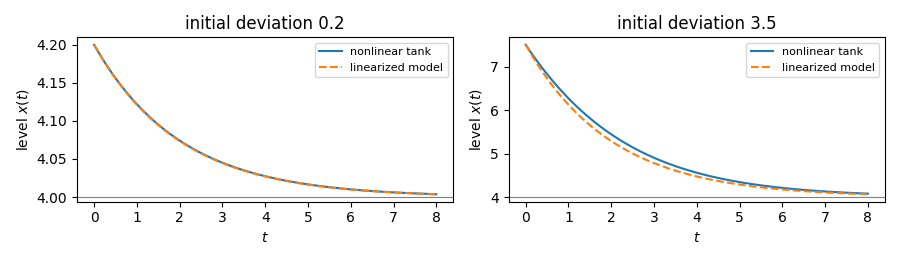

In [7]:
import matplotlib.pyplot as plt

t = np.arange(0, 8.0 + 1e-3, 1e-3)
fig, axes = plt.subplots(1, 2, figsize=(9, 2.6))
for ax, dx0 in zip(axes, (0.2, 3.5)):
    x_nl  = sim(lambda x: u_e - 2*np.sqrt(x), x_e + dx0)
    x_lin = x_e + sim(lambda dx: A_c*dx, dx0)
    ax.plot(t, x_nl, label="nonlinear tank")
    ax.plot(t, x_lin, "--", label="linearized model")
    ax.axhline(x_e, color="gray", lw=0.8)
    ax.set_title(f"initial deviation {dx0}"); ax.set_xlabel("$t$"); ax.set_ylabel("level $x(t)$")
    ax.legend(fontsize=8)
plt.tight_layout()